## Практическая работа №2. Визуализация многомерных данных. Лица Чернова

**Вариант:** 230515 mod 8 = **3** (зона F3_Z1)

**Цель:** Визуализация данных системы HVAC (отопление и вентиляция) с помощью пиктограмм (лиц Чернова) для выявления аномальных дней.

**Задачи:**
1. Загрузить данные HVAC, отфильтровать параметры зоны F3_Z1
2. Разделить на 14 дней (31 мая — 13 июня 2016)
3. Выполнить статистический анализ и корреляцию
4. Нормализовать данные
5. Создать лица Чернова для каждого дня в календарном расположении

### 1. Подключение библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Arc
import re

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

### 2. Загрузка данных и фильтрация по зоне F3_Z1

Данные HVAC из VAST Challenge 2016. Вариант 3 — зона F3_Z1 (3-й этаж, зона 1).

In [2]:
# Загрузка данных
df = pd.read_csv('csv/bldg-MC2.csv')
# Обработка колонки времени (может быть с пробелом)
time_col = [c for c in df.columns if 'Date' in c or 'Time' in c][0]
df[time_col] = pd.to_datetime(df[time_col].astype(str).str.strip())

# Фильтр колонок зоны F3_Z1 (вариант 3: 230515 mod 8 = 3)
f3z1_cols = [c for c in df.columns if re.match(r'F_3_Z_1[^0-9]', str(c).strip())]
cols_to_use = [time_col] + f3z1_cols
df_f3z1 = df[cols_to_use].copy()
df_f3z1 = df_f3z1.rename(columns={time_col: 'Date/Time'})

print(f"Загружено {len(df_f3z1)} записей, {len(f3z1_cols)} параметров зоны F3_Z1:")
for c in df_f3z1.columns[1:]:
    print(f"  - {c}")

Загружено 4032 записей, 10 параметров зоны F3_Z1:
  -  F_3_Z_1: Lights Power
  -  F_3_Z_1: Equipment Power
  -  F_3_Z_1: Thermostat Temp
  -  F_3_Z_1: Thermostat Heating Setpoint
  -  F_3_Z_1: Thermostat Cooling Setpoint
  -  F_3_Z_1 VAV REHEAT Damper Position
  -  F_3_Z_1 REHEAT COIL Power
  -  F_3_Z_1 RETURN OUTLET CO2 Concentration
  -  F_3_Z_1 SUPPLY INLET Temperature
  -  F_3_Z_1 SUPPLY INLET Mass Flow Rate


### 3. Разделение на 14 дней и агрегация

Данные охватывают период с 31 мая по 13 июня 2016. Для каждого дня вычисляем средние значения параметров.

In [3]:
# Добавляем колонку с датой
df_f3z1['Date'] = df_f3z1['Date/Time'].dt.date

# Агрегация по дням (среднее)
param_cols = [c for c in df_f3z1.columns if c not in ['Date/Time', 'Date']]
daily = df_f3z1.groupby('Date')[param_cols].mean().reset_index()

# Сортируем по дате
daily = daily.sort_values('Date').reset_index(drop=True)
print(f"Данные по {len(daily)} дням:")
daily

Данные по 14 дням:


,Date,F_3_Z_1: Lights Power,F_3_Z_1: Equipment Power,F_3_Z_1: Thermostat Temp,F_3_Z_1: Thermostat Heating Setpoint,F_3_Z_1: Thermostat Cooling Setpoint,F_3_Z_1 VAV REHEAT Damper Position,F_3_Z_1 REHEAT COIL Power,F_3_Z_1 RETURN OUTLET CO2 Concentration,F_3_Z_1 SUPPLY INLET Temperature,F_3_Z_1 SUPPLY INLET Mass Flow Rate
0,2016-05-31,181.600661,168.871957,23.606068,19.250000,24.895833,0.388740,0.000000,560.861526,12.800678,0.064665
1,2016-06-01,99.963667,123.155246,23.688490,19.250000,24.895833,0.341273,0.000000,557.171152,12.800780,0.056771
2,2016-06-02,91.633361,118.490275,26.305931,20.293125,24.999653,0.466667,1195.579868,562.914828,23.727007,0.108987
3,2016-06-03,94.965483,120.356264,28.269925,23.813333,26.800000,0.663889,2356.249784,554.440289,29.405670,0.149844
4,2016-06-04,0.000000,67.175600,27.983199,23.813333,26.800000,1.000000,2682.810545,432.746323,28.642831,0.166300
5,2016-06-05,0.000000,67.175600,27.942949,23.813333,26.800000,1.000000,2712.632799,403.719293,28.819588,0.166300
6,2016-06-06,194.929150,176.335909,28.199945,23.813333,26.800000,0.636111,2010.212934,549.115559,29.470525,0.134371
7,2016-06-07,93.299422,119.423269,28.118038,23.813333,26.800000,0.458333,1814.449635,906.999453,29.572560,0.127284
8,2016-06-08,188.264906,172.603933,28.578940,23.813333,26.800000,0.455556,1778.060468,1080.251215,28.713177,0.123702
9,2016-06-09,183.266722,169.804951,28.672964,23.813333,26.800000,0.466667,1894.558460,724.415169,28.519514,0.130245


### 4. Статистический анализ параметров

Вычисляем среднее, дисперсию, максимум и минимум для каждой переменной по всем дням.

In [4]:
# Статистики по параметрам
stats = pd.DataFrame({
    'Среднее': daily[param_cols].mean(),
    'Дисперсия': daily[param_cols].var(),
    'Максимум': daily[param_cols].max(),
    'Минимум': daily[param_cols].min(),
    'Стд. откл.': daily[param_cols].std()
})
stats.round(4)

,Среднее,Дисперсия,Максимум,Минимум,Стд. откл.
F_3_Z_1: Lights Power,99.1306,5578.3160,194.9292,0.0000,74.6881
F_3_Z_1: Equipment Power,122.6887,1749.3594,176.3359,67.1756,41.8253
F_3_Z_1: Thermostat Temp,27.4394,2.9020,28.6730,23.6061,1.7035
F_3_Z_1: Thermostat Heating Setpoint,22.9100,3.2781,23.8133,19.2500,1.8106
F_3_Z_1: Thermostat Cooling Setpoint,26.3994,0.6343,26.8000,24.8958,0.7964
F_3_Z_1 VAV REHEAT Damper Position,0.6555,0.0612,1.0000,0.3413,0.2474
F_3_Z_1 REHEAT COIL Power,1872.2293,820847.9699,2712.6328,0.0000,906.0066
F_3_Z_1 RETURN OUTLET CO2 Concentration,589.9073,37357.7113,1080.2512,403.7193,193.2814
F_3_Z_1 SUPPLY INLET Temperature,26.3923,35.3961,30.1079,12.8007,5.9495
F_3_Z_1 SUPPLY INLET Mass Flow Rate,0.1317,0.0012,0.1663,0.0568,0.0351


### 5. Матрица корреляций

Анализ связей между параметрами для обоснованного выбора схемы кодирования лиц Чернова. По исследованиям Morris et al., размер глаз и наклон бровей воспринимаются наиболее точно — для них выбираем параметры с сильной корреляцией или её нарушением при аномалиях.

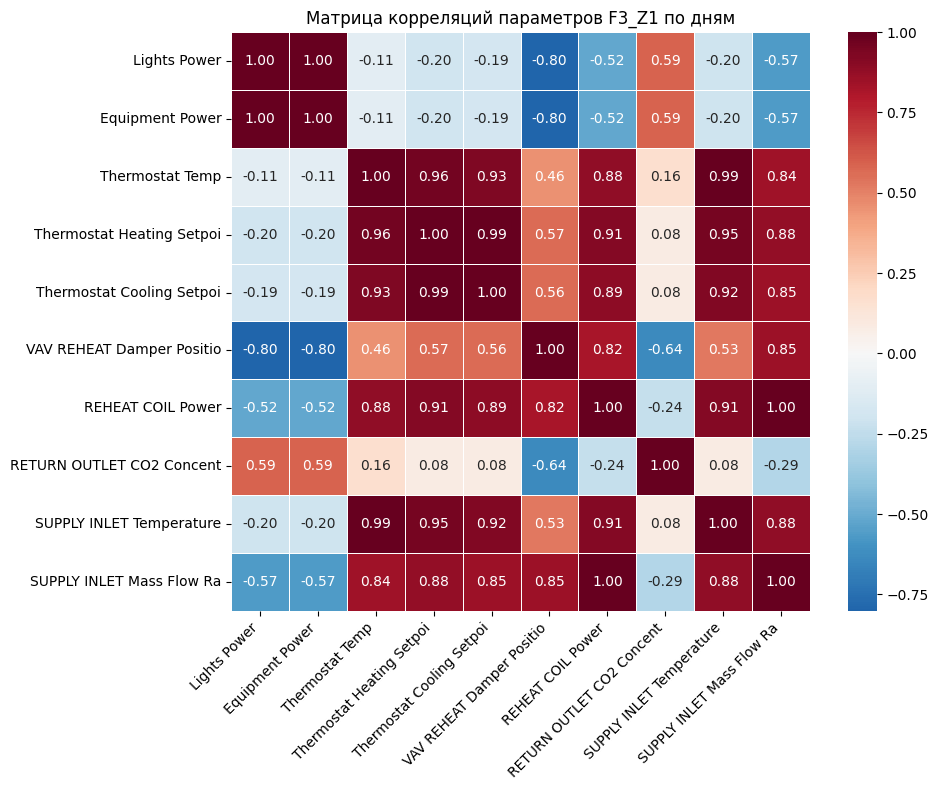

In [5]:
import seaborn as sns

# Матрица корреляций
corr = daily[param_cols].corr()
# Сокращённые названия для читаемости
short_names = {c: c.replace('F_3_Z_1', '').replace(':', '').strip()[:25] for c in param_cols}
corr_display = corr.rename(index=short_names, columns=short_names)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_display, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            square=True, linewidths=0.5, ax=ax)
plt.title('Матрица корреляций параметров F3_Z1 по дням')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 6. Нормализация и стандартизация

Приводим все параметры к единому масштабу [0, 1] для корректного отображения в лицах Чернова.

In [6]:
# Min-Max нормализация в [0, 1]
daily_norm = daily[param_cols].copy()
for col in param_cols:
    min_val = daily_norm[col].min()
    max_val = daily_norm[col].max()
    if max_val > min_val:
        daily_norm[col] = (daily_norm[col] - min_val) / (max_val - min_val)
    else:
        daily_norm[col] = 0.5  # константа

daily_norm['Date'] = daily['Date']
print("Нормализованные данные (первые 5 дней):")
daily_norm.head()

Нормализованные данные (первые 5 дней):


,F_3_Z_1: Lights Power,F_3_Z_1: Equipment Power,F_3_Z_1: Thermostat Temp,F_3_Z_1: Thermostat Heating Setpoint,F_3_Z_1: Thermostat Cooling Setpoint,F_3_Z_1 VAV REHEAT Damper Position,F_3_Z_1 REHEAT COIL Power,F_3_Z_1 RETURN OUTLET CO2 Concentration,F_3_Z_1 SUPPLY INLET Temperature,F_3_Z_1 SUPPLY INLET Mass Flow Rate,Date
0,0.931624,0.931624,0.000000,0.000000,0.000000,0.072059,0.000000,0.232276,0.000000,0.072073,2016-05-31
1,0.512821,0.512821,0.016267,0.000000,0.000000,0.000000,0.000000,0.226821,0.000006,0.000000,2016-06-01
2,0.470085,0.470085,0.532844,0.228588,0.054522,0.190358,0.440745,0.235311,0.631315,0.476733,2016-06-02
3,0.487179,0.487179,0.920456,1.000000,1.000000,0.489757,0.868621,0.222785,0.959423,0.849754,2016-06-03
4,0.000000,0.000000,0.863868,1.000000,1.000000,1.000000,0.989006,0.042906,0.915347,1.000000,2016-06-04


### 7. Схема кодирования лиц Чернова

**Обоснование выбора:** По Morris et al. размер глаз (x14) и наклон бровей (x17) воспринимаются наиболее точно. Для них выбраны параметры с высокой вариативностью и связью с аномалиями HVAC.

| Параметр данных | Черта лица | Обоснование |
|-----------------|------------|-------------|
| Thermostat Temp | Размер глаз (x14) | Ключевой показатель комфорта |
| SUPPLY INLET Temperature | Наклон бровей (x17) | Связан с работой вентиляции |
| CO2 Concentration | Кривизна рта (x8) | Качество воздуха |
| REHEAT COIL Power | Ширина рта (x9) | Нагрузка на систему |
| Damper Position | Длина носа (x6) | Положение заслонки |
| Lights Power | Размер бровей (x18) | Энергопотребление |
| Equipment Power | Вертикальная позиция глаз (x10) | Нагрузка |
| Mass Flow Rate | Разделение глаз (x11) | Поток воздуха |
| Thermostat Setpoints (avg) | Наклон глаз (x12) | Настройки |
| Heating/Cooling Setpoint diff | Позиция бровей (x16) | Режим работы |

In [17]:
def draw_chernoff_face(ax, params, face_color='wheat'):
    """
    Рисует лицо Чернова. params - dict или array с 18 значениями [0,1].
    Адаптировано из Flaxman (CC BY-NC-SA 3.0)
    """
    # Извлекаем 18 параметров, по умолчанию 0.5
    p = [0.5] * 18
    if isinstance(params, dict):
        for i, v in params.items():
            if 0 <= i < 18:
                p[i] = np.clip(v, 0.001, 0.999)
    else:
        for i, v in enumerate(params[:18]):
            p[i] = np.clip(v, 0.001, 0.999)
    
    x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18 = p
    
    # Преобразования для разнообразия при входе [0,1]
    x3 = 1.9*(x3-.5)
    x4 = (x4+.25)
    x5 = (x5+.2)
    x6 = .3*(x6+.01)
    x8 = 5*(x8+.001)
    x11 /= 5
    x12 = 2*(x12-.5)
    x13 = np.clip(x13 + .05, 0.1, 1)
    x14 = np.clip(x14 + .1, 0.1, 1)
    x15 = .5*(x15-.5)
    x16 = .25*x16
    x17 = .5*(x17-.5)
    x18 = .5*(x18+.1)

    # Лицо
    e = Ellipse((0, (x1+x3)/2), 2*x4, (x1-x3), fc=face_color, ec='black', linewidth=1.5)
    ax.add_artist(e)
    e = Ellipse((0, (-x1+x2+x3)/2), 2*x5, (x1+x2+x3), fc=face_color, ec='black', linewidth=1.5)
    ax.add_artist(e)
    e = Ellipse((0, (x1+x3)/2), 2*x4, (x1-x3), fc=face_color, ec='none')
    ax.add_artist(e)
    e = Ellipse((0, (-x1+x2+x3)/2), 2*x5, (x1+x2+x3), fc=face_color, ec='none')
    ax.add_artist(e)
    
    # Нос
    ax.plot([0, 0], [-x6/2, x6/2], 'k', lw=1.5)
    
    # Рот
    arc = Arc((0, -x7+.5/x8), 1/x8, 1/x8, theta1=270-180/np.pi*np.arctan(x8*x9), 
              theta2=270+180/np.pi*np.arctan(x8*x9), lw=1.5)
    ax.add_artist(arc)
    
    # Глаза
    e = Ellipse((-x11-x14/2, x10), x14, x13*x14, angle=-180/np.pi*x12, facecolor='white', ec='black', lw=1)
    ax.add_artist(e)
    e = Ellipse((x11+x14/2, x10), x14, x13*x14, angle=180/np.pi*x12, facecolor='white', ec='black', lw=1)
    ax.add_artist(e)
    # Зрачки
    e = Ellipse((-x11-x14/2-x15*x14/2, x10), .05, .05, facecolor='black')
    ax.add_artist(e)
    e = Ellipse((x11+x14/2-x15*x14/2, x10), .05, .05, facecolor='black')
    ax.add_artist(e)
    
    # Брови
    ax.plot([-x11-x14/2-x14*x18/2, -x11-x14/2+x14*x18/2],
            [x10+x13*x14*(x16+x17), x10+x13*x14*(x16-x17)], 'k', lw=1.5)
    ax.plot([x11+x14/2+x14*x18/2, x11+x14/2-x14*x18/2],
            [x10+x13*x14*(x16+x17), x10+x13*x14*(x16-x17)], 'k', lw=1.5)
    
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.2, 2.1)
    ax.set_aspect('equal')
    ax.axis('off')

def draw_symmetric_chernoff_face(ax, params, face_color='wheat'):
    """Симметричное лицо (как в схеме), черты варьируются по params [0,1]."""
    p = [0.5] * 18
    if isinstance(params, dict):
        for i, v in params.items():
            if 0 <= i < 18: p[i] = np.clip(v, 0.001, 0.999)
    else:
        for i, v in enumerate(params[:18]):
            p[i] = np.clip(v, 0.001, 0.999)
    # Индексы: 5-нос, 7-кривизна рта, 8-ширина рта, 9-поз. глаз, 10-разделение, 11-наклон глаз,
    # 13-размер глаз, 15-поз. бровей, 16-наклон бровей, 17-размер бровей
    eye_size = 0.12 + 0.16 * p[13]
    eye_sep = 0.25 + 0.2 * p[10]
    eye_y = 0.28 + 0.14 * p[9]
    brow_y = 0.48 + 0.12 * p[15]
    brow_len = 0.08 + 0.12 * p[17]
    brow_tilt = 0.03 * (p[16] - 0.5)
    nose_len = 0.12 + 0.2 * p[5]
    mouth_w = 0.35 + 0.25 * p[8]
    mouth_arc = 40 + 80 * p[7]
    eye_tilt = 10 * (p[11] - 0.5)
    # Лицо
    ax.add_artist(Ellipse((0, 0), 1.4, 1.8, fc=face_color, ec='black', lw=1.5))
    # Глаза
    for sx in [-1, 1]:
        cx, cy = sx * eye_sep, eye_y
        e = Ellipse((cx, cy), eye_size, eye_size*0.6, angle=eye_tilt, facecolor='white', ec='black', lw=1)
        ax.add_artist(e)
        ax.add_artist(Ellipse((cx, cy), 0.04, 0.04, facecolor='black'))
    # Брови
    for sx in [-1, 1]:
        x1, x2 = sx*eye_sep - brow_len, sx*eye_sep + brow_len
        y1 = brow_y + brow_tilt
        y2 = brow_y - brow_tilt
        ax.plot([x1, x2], [y1, y2], 'k', lw=1.5)
    # Нос
    ax.plot([0, 0], [-nose_len/2, nose_len/2], 'k', lw=1.5)
    # Рот
    ax.add_artist(Arc((0, -0.35), mouth_w, 0.25, theta1=270-mouth_arc/2, theta2=270+mouth_arc/2, lw=1.5))
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.2, 1.2)
    ax.set_aspect('equal')
    ax.axis('off')

In [18]:
# Маппинг: индекс в param_cols -> индекс черты лица Чернова (0-17)
# x0-x17: верх лица, низ лица, половинный размер, ширина верха, ширина низа,
# длина носа, позиция рта, кривизна рта, ширина рта, позиция глаз, разделение глаз,
# наклон глаз, эксцентриситет глаз, размер глаз, позиция зрачков, позиция бровей,
# наклон бровей, размер бровей
PARAM_TO_FACE = {
    0: 17,   # Lights Power -> размер бровей (x18)
    1: 9,    # Equipment Power -> вертикальная позиция глаз (x10)
    2: 13,   # Thermostat Temp -> размер глаз (x14, важнейший!)
    3: 15,   # Heating Setpoint -> вертикальная позиция бровей (x16)
    4: 11,   # Cooling Setpoint -> наклон глаз (x12)
    5: 5,    # Damper Position -> длина носа (x6)
    6: 8,    # REHEAT COIL Power -> ширина рта (x9)
    7: 7,    # CO2 Concentration -> кривизна рта (x8)
    8: 16,   # SUPPLY Temperature -> наклон бровей (x17, важнейший!)
    9: 10,   # Mass Flow Rate -> разделение глаз (x11)
}

def row_to_face_params(row):
    """Преобразует строку нормализованных данных в 18 параметров лица."""
    p = [0.5] * 18
    for i, col in enumerate(param_cols):
        if i in PARAM_TO_FACE:
            idx = PARAM_TO_FACE[i]
            p[idx] = row[col]
    return p

### 8. Визуализация: 14 лиц Чернова в календарном расположении

Располагаем лица по дням (2 строки × 7 столбцов) для удобного сравнения день за днём.

In [19]:
# Цвет лица: от «нормального» (светлый) к «аномальному» (более тёмный/красноватый)
# Используем отклонение от среднего по всем параметрам
baseline = daily_norm[param_cols].mean()
deviation = (daily_norm[param_cols] - baseline).abs().mean(axis=1)
dev_norm = (deviation - deviation.min()) / (deviation.max() - deviation.min() + 1e-8)
face_colors = [plt.cm.YlOrRd(0.3 + 0.5 * v) for v in dev_norm]

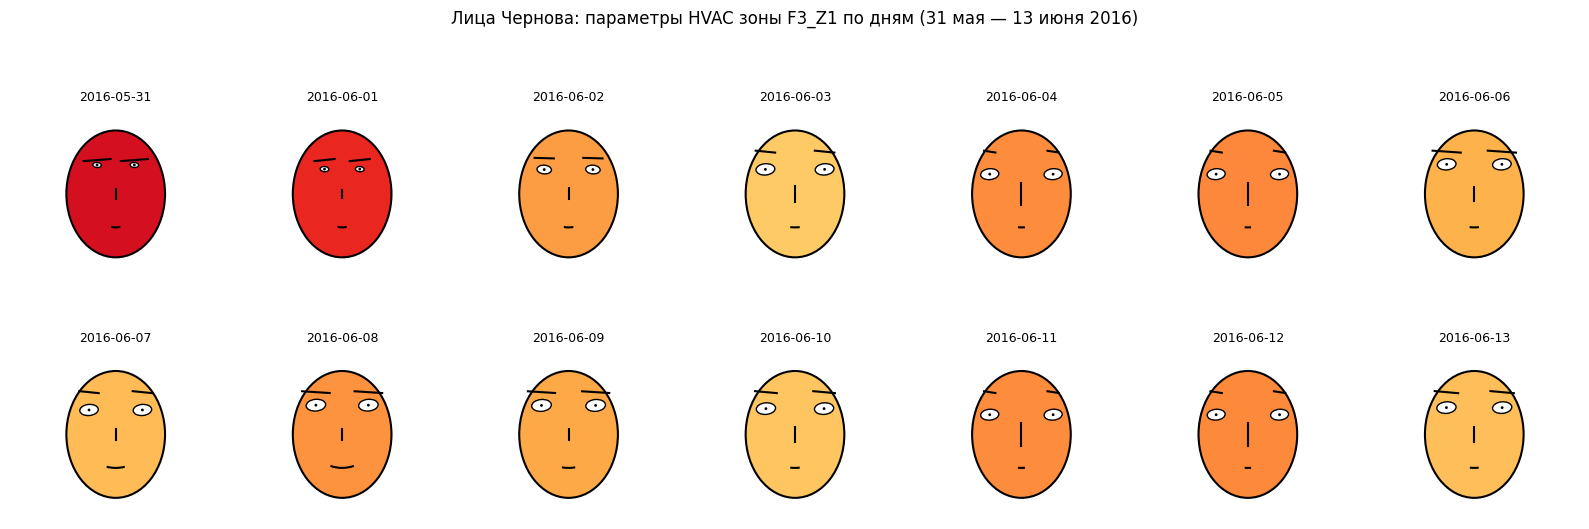

In [20]:
# Сетка 2×7 для 14 дней
fig, axes = plt.subplots(2, 7, figsize=(16, 6), subplot_kw={'aspect': 'equal'})
axes = axes.flatten()

for idx, (i, row) in enumerate(daily_norm.iterrows()):
    ax = axes[idx]
    params = row_to_face_params(row)
    color = face_colors[idx]
    draw_symmetric_chernoff_face(ax, params, face_color=color)
    date_str = str(row['Date'])
    ax.set_title(date_str, fontsize=9)

# Скрываем лишние оси
for idx in range(len(daily_norm), 14):
    axes[idx].axis('off')

plt.suptitle('Лица Чернова: параметры HVAC зоны F3_Z1 по дням (31 мая — 13 июня 2016)', fontsize=12)
plt.tight_layout()
plt.savefig('chernoff_calendar.png', dpi=150, bbox_inches='tight')
plt.show()

### 9. Анализ результатов: выявление аномальных дней

**Вопросы задания:**
1. В какие дни возникали аномальные ситуации в системе HVAC?
2. Какие параметры связаны с аномалиями?

In [11]:
# Дни с наибольшим отклонением от среднего
z_scores = (daily[param_cols] - daily[param_cols].mean()) / (daily[param_cols].std() + 1e-8)
daily['Anomaly_Score'] = z_scores.abs().mean(axis=1)
anomalous = daily.nlargest(5, 'Anomaly_Score')[['Date', 'Anomaly_Score']]
print("Дни с наибольшим отклонением (потенциальные аномалии):")
print(anomalous.to_string(index=False))

# Параметры с наибольшей вариативностью между днями
var_by_param = daily[param_cols].var().sort_values(ascending=False)
print("\nПараметры с наибольшей вариативностью (могут указывать на аномалии):")
print(var_by_param.head(5).to_string())

Дни с наибольшим отклонением (потенциальные аномалии):
      Date  Anomaly_Score
2016-05-31       1.585394
2016-06-01       1.405506
2016-06-05       0.862913
2016-06-12       0.855948
2016-06-04       0.843995

Параметры с наибольшей вариативностью (могут указывать на аномалии):
F_3_Z_1 REHEAT COIL Power                  820847.969923
F_3_Z_1 RETURN OUTLET CO2 Concentration     37357.711272
F_3_Z_1: Lights Power                        5578.316008
F_3_Z_1: Equipment Power                     1749.359431
F_3_Z_1 SUPPLY INLET Temperature               35.396134


### 10. Рисунок схемы визуализации

Схема кодирования параметров HVAC в черты лица Чернова.

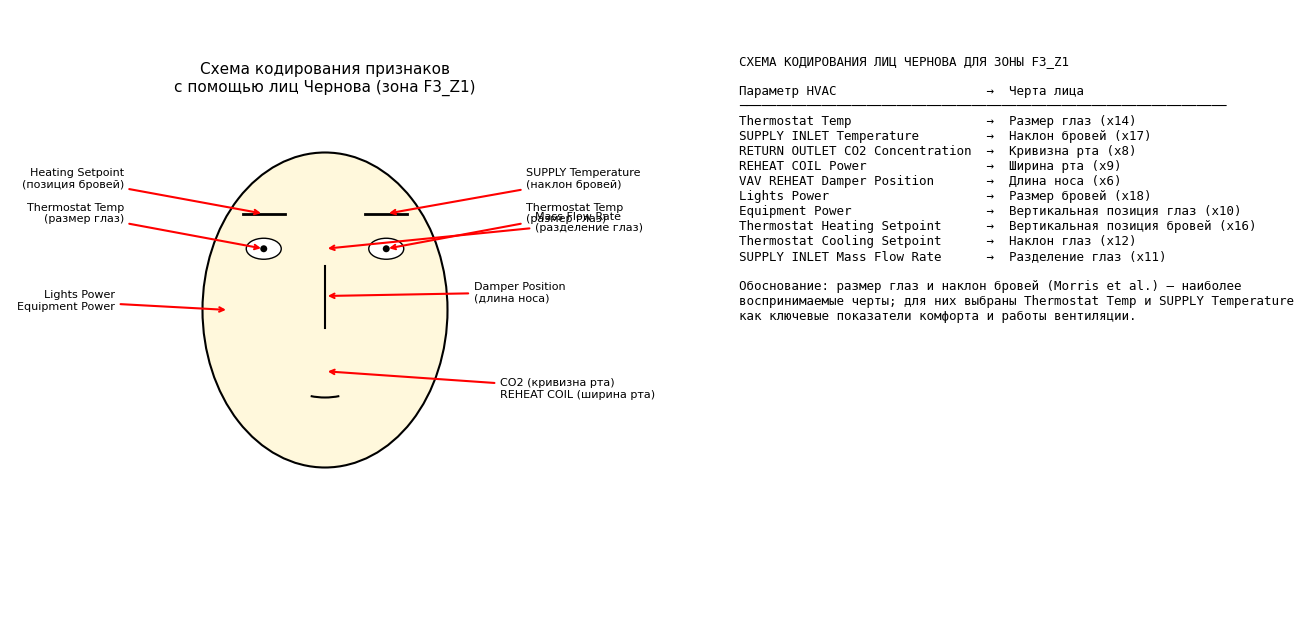

In [21]:
# Схема кодирования для отчёта: симметричное лицо с точными стрелками (как на рис. 11)
def draw_schema_face(ax, face_color='#FFF8DC'):
    """Рисует симметричное схематичное лицо для диаграммы. Возвращает координаты черт."""
    # Симметричный овал лица
    face = Ellipse((0, 0), 1.4, 1.8, fc=face_color, ec='black', lw=1.5)
    ax.add_artist(face)
    # Глаза (симметричные)
    eye_y, eye_sep, eye_w, eye_h = 0.35, 0.35, 0.2, 0.12
    for sx in [-1, 1]:
        e = Ellipse((sx * eye_sep, eye_y), eye_w, eye_h, facecolor='white', ec='black', lw=1)
        ax.add_artist(e)
        ax.add_artist(Ellipse((sx * eye_sep, eye_y), 0.04, 0.04, facecolor='black'))
    # Брови (чётко видимые линии над глазами)
    brow_y = 0.55
    for sx in [-1, 1]:
        ax.plot([sx*eye_sep - 0.12, sx*eye_sep + 0.12], [brow_y, brow_y], 'k', lw=2)
    # Нос (вертикальная линия)
    ax.plot([0, 0], [-0.1, 0.25], 'k', lw=1.5)
    # Рот (дуга)
    mouth = Arc((0, -0.35), 0.5, 0.3, theta1=240, theta2=300, lw=1.5)
    ax.add_artist(mouth)
    # Координаты для стрелок (центры черт)
    return {
        'left_eye': (-eye_sep, eye_y), 'right_eye': (eye_sep, eye_y),
        'left_brow': (-eye_sep, brow_y), 'right_brow': (eye_sep, brow_y),
        'nose': (0, 0.08), 'mouth': (0, -0.35),
        'left_face': (-0.55, 0.0), 'right_face': (0.55, 0.0),
        'between_eyes': (0, eye_y),
    }

fig = plt.figure(figsize=(14, 8))
ax_face = fig.add_axes([0.05, 0.15, 0.45, 0.75])
ax_face.set_xlim(-1.8, 1.8)
ax_face.set_ylim(-1.2, 1.2)
ax_face.set_aspect('equal')
ax_face.axis('off')

coords = draw_schema_face(ax_face)

# Стрелки: xy — точка на черте лица, xytext — подпись
annotations = [
    (coords['right_eye'], (1.15, 0.5), "Thermostat Temp\n(размер глаз)", 'left'),
    (coords['left_eye'], (-1.15, 0.5), "Thermostat Temp\n(размер глаз)", 'right'),
    (coords['right_brow'], (1.15, 0.7), "SUPPLY Temperature\n(наклон бровей)", 'left'),
    (coords['left_brow'], (-1.15, 0.7), "Heating Setpoint\n(позиция бровей)", 'right'),
    (coords['mouth'], (1.0, -0.5), "CO2 (кривизна рта)\nREHEAT COIL (ширина рта)", 'left'),
    (coords['nose'], (0.85, 0.05), "Damper Position\n(длина носа)", 'left'),
    (coords['left_face'], (-1.2, 0.0), "Lights Power\nEquipment Power", 'right'),
    (coords['between_eyes'], (1.2, 0.45), "Mass Flow Rate\n(разделение глаз)", 'left'),
]
for (xy, xytext, label, ha) in annotations:
    ax_face.annotate(label, xy=xy, xytext=xytext, fontsize=8, ha=ha,
                     arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

ax_face.set_title('Схема кодирования признаков\nс помощью лиц Чернова (зона F3_Z1)', fontsize=11)

# Текстовая легенда справа
ax_text = fig.add_axes([0.55, 0.15, 0.42, 0.75])
ax_text.axis('off')
schema_text = """
СХЕМА КОДИРОВАНИЯ ЛИЦ ЧЕРНОВА ДЛЯ ЗОНЫ F3_Z1

Параметр HVAC                    →  Черта лица
─────────────────────────────────────────────────────────────────
Thermostat Temp                  →  Размер глаз (x14)
SUPPLY INLET Temperature         →  Наклон бровей (x17)
RETURN OUTLET CO2 Concentration  →  Кривизна рта (x8)
REHEAT COIL Power                →  Ширина рта (x9)
VAV REHEAT Damper Position       →  Длина носа (x6)
Lights Power                     →  Размер бровей (x18)
Equipment Power                  →  Вертикальная позиция глаз (x10)
Thermostat Heating Setpoint      →  Вертикальная позиция бровей (x16)
Thermostat Cooling Setpoint      →  Наклон глаз (x12)
SUPPLY INLET Mass Flow Rate      →  Разделение глаз (x11)

Обоснование: размер глаз и наклон бровей (Morris et al.) — наиболее
воспринимаемые черты; для них выбраны Thermostat Temp и SUPPLY Temperature
как ключевые показатели комфорта и работы вентиляции.
"""
ax_text.text(0.05, 0.95, schema_text, transform=ax_text.transAxes, fontsize=9, 
             verticalalignment='top', fontfamily='monospace')
plt.savefig('schema_visualization.png', dpi=150, bbox_inches='tight')
plt.show()